## Geometric setting
Let $ N \in \mathbb{N} $, and for each $ k = 1, \dots, N $, let $ \Omega_k \subset \mathbb{R}^3 $ be a Lipschitz domain with the boundary $\Gamma_k := \partial \Omega_k$.  Let $\Omega_k$ be pairwise disjoint, i.e. it holds that $\overline{\Omega_k} \cap \overline{\Omega_\ell} = \emptyset$, for all $k \neq \ell$. We denote by $ \boldsymbol{c}_k \in \Omega_k$ a fixed point in $\Omega_k$. Let $\Omega^c := \mathbb{R}^3 \setminus \overline{\Omega}$ denote the exterior domain.
	
Let $ \varepsilon \in (0, 1] $ be a scaling parameter. The rescaled domains $ \Omega_k^{\varepsilon} $ are defined by
$$
\Omega^{\varepsilon}_k := \{ \boldsymbol{x} \in \mathbb{R}^3: \boldsymbol{x} = \varepsilon (\hat{\boldsymbol{x}} - \boldsymbol{c}_k) + \boldsymbol{c}_k, \,\hat{\boldsymbol{x}} \in \Omega_k \}.
$$
By this definition, the rescaled domain is given by $ \Omega^{\varepsilon} = \bigcup_{k=1}^N \Omega_k^{\varepsilon} $, with boundary $ \Gamma^{\varepsilon} = \bigcup_{k=1}^N \Gamma_k^{\varepsilon} $. For brevity, we use the notations $\Omega$ and $\Gamma$ instead of $\Omega^1$ and $\Gamma^1$.

---

##  Mathematical problem 

In this demo code, we consider the following problem of time-domain sound-soft scattering by multiple small particles. Namely, we look for the total field $u^{\varepsilon, \operatorname{tot}}$ in the form $u^{\varepsilon} + u^{\operatorname{inc}} $, where $ u^{\varepsilon} $ is the scattered field that satisfies the wave equation with the inhomogeneous Dirichlet boundary conditions in $\Omega^{\varepsilon, c}$:
$$
\begin{cases}
    \partial^2_t u^{\varepsilon}(\boldsymbol{x}, t) - \Delta u^{\varepsilon}(\boldsymbol{x}, t) = 0 & \text{in } \Omega^{\varepsilon, c} \times \mathbb{R}_{>0} \\
    u^{\varepsilon}(\boldsymbol{x}, t) = -u^{\operatorname{inc}}(\boldsymbol{x}, t) & \text{on } \Gamma^{\varepsilon} \times \mathbb{R}_{>0} \\
    u^{\varepsilon}(\boldsymbol{x}, 0) = \partial_t u^{\varepsilon}(\boldsymbol{x}, 0) = 0 & \text{in } \Omega^{\varepsilon, c}
\end{cases}
$$
where 
*   $u^{\operatorname{inc}}$: The incident field (e.g. Modulated Gaussian Pulse) that satisfies the free-space wave equatio $\partial^2_t u^{\operatorname{inc}}(\boldsymbol{x}, t) - \Delta u^{\operatorname{inc}}(\boldsymbol{x}, t) = 0$.
*   Causality condition: We assume that at $t=0$, the support of $u^{\operatorname{inc}}$ is located outside the obstacle domain $\Omega^{\varepsilon}$, meaning the wave has not yet reached the particles at the start of the simulation.
*   $\varepsilon$: The small scaling parameter representing the characteristic size of the particles. 


In [11]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
import os
import numpy as np
import gmsh
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.tri as tri

import bempp.api

from IPython.display import Image, display, HTML

from utils.geometry import *
from plot_helpers import *

In [13]:
# Plot style 
apply_plot_style()

## Motivation: Why Asymptotic Models?

Standard numerical approaches, such as Finite Element Methods (FEM) or Boundary Element Methods (BEM), face significant challenges when dealing with small-scale obstacles. 

To accurately approximate the scattered field, these classical methods require highly refined meshes in the neighborhood of each particle $\Omega^\varepsilon_k$. This multiscale nature of the problem leads to:

*   Prohibitive Computational Cost: The number of degrees of freedom increases greatly as the small parameter $\varepsilon \to 0$.
*   Memory Bottlenecks: Storing and inverting large-scale system matrices becomes impractical on standard workstations.

The figure below illustrates a mesh generated using GMSH for a single small particle.

Info    : Meshing 1D...                                                                                                                        
Info    : [  0%] Meshing curve 5 (Ellipse)
Info    : [ 30%] Meshing curve 6 (Line)
Info    : [ 50%] Meshing curve 7 (Line)
Info    : [ 70%] Meshing curve 8 (Line)
Info    : [ 90%] Meshing curve 9 (Line)
Info    : Done meshing 1D (Wall 0.000183708s, CPU 0.0002s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.0272834s, CPU 0.027024s)
Info    : 1045 nodes 2095 elements


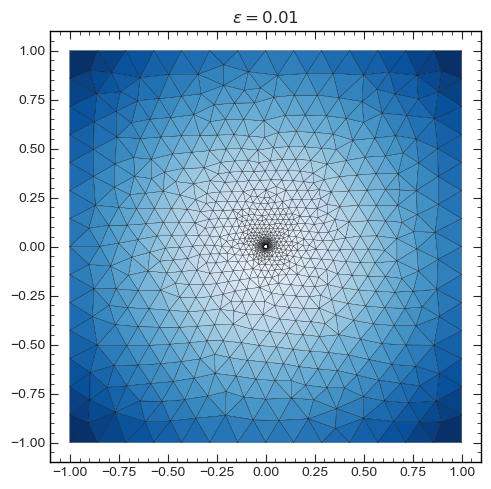

In [14]:
# Illustration of a mesh generated around a small sphere of radius r = eps centered at origin.

def plot_computational_mesh(r=0.08, mesh_far=0.15, mesh_near=0.005):
    gmsh.initialize()
    gmsh.model.add("Mesh_Visualization")

    # Geometry construction using OpenCASCADE
    square = gmsh.model.occ.addRectangle(-1, -1, 0, 2, 2)
    circle = gmsh.model.occ.addDisk(0, 0, 0, r, r)
    gmsh.model.occ.cut([(2, square)], [(2, circle)])
    gmsh.model.occ.synchronize()

    # Local mesh refinement near the obstacle boundary
    pts = gmsh.model.getEntities(0)
    for dim, tag in pts:
        x, y, _ = gmsh.model.getValue(dim, tag, [])
        dist = np.sqrt(x**2 + y**2)
        size = mesh_near if dist < r * 1.5 else mesh_far
        gmsh.model.mesh.setSize([(dim, tag)], size)

    gmsh.model.mesh.generate(2)

    # Extract mesh data for Matplotlib rendering
    _, coords, _ = gmsh.model.mesh.getNodes()
    nodes = coords.reshape((-1, 3))[:, :2]
    _, _, node_idx = gmsh.model.mesh.getElements(2)
    triangles = (node_idx[0].reshape((-1, 3)) - 1).astype(int)
    gmsh.finalize()

    # Visualization
    plt.figure(figsize=(5, 5))
    triang = tri.Triangulation(nodes[:, 0], nodes[:, 1], triangles)
    plt.tripcolor(triang, np.linalg.norm(nodes, axis=1), cmap='Blues', edgecolors='k', lw=0.2)
    plt.gca().set_aspect('equal')
    plt.title(rf"$\varepsilon={r}$")
    plt.show()

plot_computational_mesh(r=0.01, mesh_far=0.15, mesh_near=0.001)

# Asymptotic Models

On the other hand, a frequency-domain argument shows that $\| u^{\varepsilon} \|_{L^{\infty}(0,T; L^{\infty}(K))}$ is $O(\varepsilon)$ for any compact subset $K$ of $\Omega^c$. However, in many practical applications, simply approximating the scattered field $u^{\varepsilon}$ by zero is insufficient for capturing the necessary wave interactions. 

To address this, we present three time-stable higher-order asymptotic models valid in the regime $\varepsilon \to 0$. These models allow for the construction of an accurate approximate solution $u^{\varepsilon}_{\operatorname{app}}$ of the scattered field $u^{\varepsilon}$:

---

### **Asymptotic model 1: Galerkin Foldy-Lax (GFL)**
The approximate scattered field takes the following form:
$$
u^{\varepsilon}_{G,\operatorname{app}} (\boldsymbol{x}, t) = \sum_{k=1}^N \int_{\Gamma^{\varepsilon}_k} \frac{\lambda^{\varepsilon}_{G,k}(t-|\boldsymbol{x}-\boldsymbol{y}|)}{4\pi | \boldsymbol{x}-\boldsymbol{y} |} \sigma_k^{\varepsilon}(\boldsymbol{y}) \, d\Gamma_{\boldsymbol{y}}, \quad (\boldsymbol{x}, t) \in \Omega^{\varepsilon, c} \times \mathbb{R}_{>0},
$$
where the time-dependent real-valued functions $\{ \lambda^{\varepsilon}_{G,k}(\cdot) \}_{k=1}^N$ solve the following linear convolutional in time system:
$$
\begin{cases}
\sum_{k=1}^N (K^{\varepsilon}_{G,\ell k } * \lambda^{\varepsilon}_{G,k})(t) = q_{G,\ell }^{\varepsilon}(t) \\
(K^{\varepsilon}_{G,\ell k } * \lambda^{\varepsilon}_{G,k})(t) = \int_{\Gamma_k^{\varepsilon}} \int_{\Gamma_{\ell}^{\varepsilon}} \frac{\lambda^{\varepsilon}_{G,k}(t-|\boldsymbol{x}-\boldsymbol{y}|)}{4\pi|\boldsymbol{x}-\boldsymbol{y}|} \sigma_k^{\varepsilon}(\boldsymbol{x}) \sigma_{\ell}^{\varepsilon}(\boldsymbol{y}) d\Gamma_{\boldsymbol{x}} \, d\Gamma_{\boldsymbol{y}} \\
q^{\varepsilon}_{G, \ell}(t) = -\int_{\Gamma^{\varepsilon}_{\ell}} u^{\operatorname{inc}} (\boldsymbol{x}, t) \sigma_{\ell}^{\varepsilon}(\boldsymbol{x}) d\Gamma_{\boldsymbol{x}}
\end{cases}
$$
and $\sigma_k^{\varepsilon} \in H^{-1/2}(\Gamma^{\varepsilon}_k)$ satisfies the following problem: $\int_{\Gamma_k^{\varepsilon}} \frac{\sigma_k^{\varepsilon}(\boldsymbol{y})}{4 \pi | \boldsymbol{x} - \boldsymbol{y}|} \, d\Gamma_{\boldsymbol{y}} = 1$ on $\Gamma_k^{\varepsilon}$. The numerical implementation of this model is available in [`src/asymptotic_solvers/time_domain/gfl.py`](../src/asymptotic_solvers/time_domain/gfl.py).


---

### **Asymptotic model 2: Simplified Galerkin Foldy-Lax (SGFL)**

The equilibrium densities $\sigma_k^{\varepsilon}$ in the Galerkin-Foldy Lax model can be computed once and reused for all $\varepsilon \in (0,1)$. However, the numerical implementation of this model relies on computing heavy surface integrals $\Gamma_{k}^{\varepsilon} \times \Gamma_{\ell}^{\varepsilon}$. This motivates the use of the following simplified model.

Let us set the following quantities:
$$
c_k^{\varepsilon} := \int_{\Gamma^{\varepsilon}_k} \sigma^{\varepsilon}_k(\boldsymbol{y}) d\Gamma_{\boldsymbol{y}}, \quad \mathbf{p}_k^{\varepsilon} := \int_{\Gamma^{\varepsilon}_k} (\boldsymbol{y} - \boldsymbol{c}_k) \sigma_k^{\varepsilon}(\boldsymbol{y}) d\Gamma_{\boldsymbol{y}}
$$
With these definitions, the approximated scattered field takes the simplified form:
$$
u^{\varepsilon}_{s,\operatorname{app}}(\boldsymbol{x},t) = \sum_{k=1}^N \frac{\lambda^{\varepsilon}_{s,k}(t-|\boldsymbol{x}-\boldsymbol{c}_k|)}{4\pi|\boldsymbol{x}-\boldsymbol{c}_k|} \left(c_k^{\varepsilon} + \frac{(\boldsymbol{x}-\boldsymbol{c}_k)}{4\pi|\boldsymbol{x}-\boldsymbol{c}_k|^3} \cdot \mathbf{p}_k^{\varepsilon}\right) + \sum_{k=1}^N \frac{\partial_t \lambda^{\varepsilon}_{s,k}(t-|\boldsymbol{x}-\boldsymbol{c}_k|)}{4\pi|\boldsymbol{x}-\boldsymbol{c}_k|^2}(\boldsymbol{x}-\boldsymbol{c}_k) \cdot \mathbf{p}_k^{\varepsilon}
$$
where the functions $\{ \lambda^{\varepsilon}_{s,k}(\cdot) \}_{k=1}^N$ solve the linear convolutional system:
$$
\sum_{k=1}^N (K^{\varepsilon}_{s, \ell k } * \lambda^{\varepsilon}_{s, k})(t) = q_{s}^{\varepsilon,\ell }(t)
$$
with:
*   $q^{\varepsilon}_{s, \ell}(t) = -u^{\operatorname{inc}}(\boldsymbol{c}_{\ell},t) c_{\ell}^{\varepsilon} - \nabla u^{\operatorname{inc}}(\boldsymbol{c}_{\ell}, t) \cdot \mathbf{p}_{\ell}^{\varepsilon}$
*   $K^{\varepsilon}_{s, \ell k }(t) = \mathcal{F}^{-1} (\mathbb{M}^{\varepsilon}_{s, \ell k})(t)$, where $\mathcal{F}^{-1}$ is the inverse Fourier-Laplace transform.

The matrix $\mathbb{M}^{\varepsilon}_{s}$ is given by:
$$
\mathbb{M}^{\varepsilon}_{s, \ell k}(\omega) = 
\begin{cases} 
4 \pi i \omega (\rho^{\varepsilon}_k)^2 j_0(\omega \rho^{\varepsilon}_k) h^{(1)}_0(\omega \rho^{\varepsilon}_k), & k = \ell \\
4 \pi i \omega \rho^{\varepsilon}_k \rho^{\varepsilon}_{\ell} j_0(\omega \rho^{\varepsilon}_k) j_0(\omega \rho^{\varepsilon}_{\ell}) h^{(1)}_0(\omega |\boldsymbol{c}_k - \boldsymbol{c}_{\ell}| ), & k \neq \ell 
\end{cases}
$$
with $\rho^{\varepsilon}_k := c^{\varepsilon}_k / 4\pi$, and $j_0, h^{(1)}_0$ being the spherical Bessel and Hankel functions. The numerical implementation of this model is available in [`src/asymptotic_solvers/time_domain/gfl.py`](../src/asymptotic_solvers/time_domain/sgfl.py).

---

### **Asymptotic model 3: Born approximation**
The Born approximation assumes no interaction between particles. The approximated scattered field is given explicitly by:
$$
u^{\varepsilon}_{B,\operatorname{app}}(\boldsymbol{x},t) = -\sum_{k=1}^N \frac{u^{\operatorname{inc}}(\boldsymbol{c}_k, t-|\boldsymbol{x}-\boldsymbol{c}_k|)}{4\pi|\boldsymbol{x}-\boldsymbol{c}_k|} c_k^{\varepsilon}.
$$


---

Numerical experiments demonstrate the following absolute error convergence rates as ($\varepsilon \to 0$):

*   **GFL & Simplified GFL:** Both models achieve cubic convergence, $O(\varepsilon^3)$.
*   **Born Approximation:** Achieves quadratic convergence, $O(\varepsilon^2)$.

While the GFL models offer higher-order accuracy, the **Simplified GFL** and **Born approximation** are particularly recommended for their robustness in practical simulations.

# Numerical Experiments 

### **Experiment: GFL vs SGFL vs Born vs BEM**

In this experiment, we employ a Modulated Gaussian Pulse as the incident field $u^{\operatorname{inc}}$. The analytical form of the incident pulse is given by:

$$
u^{\operatorname{inc}}(\boldsymbol{x}, t) = \cos\left( \omega(t - \boldsymbol{x} \cdot \vec{d}) \right) \, e^{-\sigma(t - \boldsymbol{x} \cdot \vec{d} - \mu)^2}, 
$$

with $\omega = 2\pi, ~ \sigma = 3, ~ \mu = 3, ~ \vec{d} = \frac{1}{\sqrt{3}}(1, -1, 1)$.

In [15]:
# Upload the data 
data_path = os.path.join("..", "data", "cavity_scattering_n5.npz")
data = np.load(data_path, allow_pickle=True)

In [ ]:
# Visualization of the Geometric Setting 
centers, geomtry, directions, angles = [data['centers'], data['geometry'], data['directions'], data['angles']]

grid_list = select_geometry(geomtry, centers, epsilon=0.5, directions=directions, angles=angles)
grid_merged = bempp.api.grid.union(grid_list)

visualize_grid(grid_merged)


<p align="center">
  <img src="https://github.com/savchuk-adrian/asymptotic-models-phd/raw/main/notebooks/pictures/five_particles_with_cavity.png" width="600">
</p>

<p align="center">
  <em> Geometric configuration for eps = 0.5. The obstacles are centered at the vertices of a regular tetrahedron and at the origin.</em>
</p>

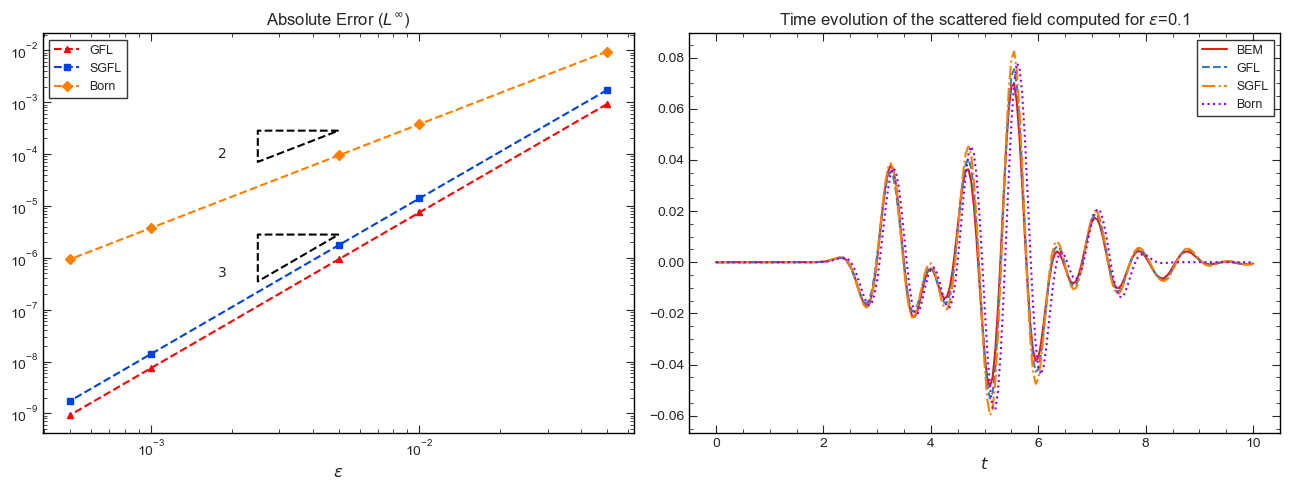

In [16]:
fig, (ax_curves, ax_fields) = plt.subplots(1, 2, figsize=(13, 5))

# Visualisation of convergence curves
errors_bem_vs_gfl = []
errors_bem_vs_sgfl = []
errors_bem_vs_born = []

epsilons = data['epsilon_list']

for eps in epsilons:
    eps = str(eps).replace('.', '_')

    u_bem = data[f'u_BEM_{eps}']
    u_gfl = data[f'u_G_{eps}']
    u_sgfl = data[f'u_s_{eps}']
    u_born = data[f'u_B_{eps}']

    err_bem_vs_gfl = np.linalg.norm(u_bem-u_gfl, ord=np.inf)
    errors_bem_vs_gfl.append(err_bem_vs_gfl)

    err_bem_vs_sgfl = np.linalg.norm(u_bem-u_sgfl, ord=np.inf)
    errors_bem_vs_sgfl.append(err_bem_vs_sgfl)

    err_bem_vs_born = np.linalg.norm(u_bem-u_born, ord=np.inf)
    errors_bem_vs_born.append(err_bem_vs_born)

error_curves = {
    'GFL': errors_bem_vs_gfl,
    'SGFL': errors_bem_vs_sgfl,
    'Born': errors_bem_vs_born
}


plot_convergence_curves(ax_curves, epsilons, **error_curves)

add_convergence_triangle(ax_curves, epsilons[2], errors_bem_vs_born[2], 2, size_x=0.5, text_offset=0.2, shift_y=3)
add_convergence_triangle(ax_curves, epsilons[2], errors_bem_vs_gfl[2], 3, size_x=0.5, text_offset=0.2, shift_y=3)


# Visualisation of scattered fields 
eps = 0.1
eps_str = str(eps).replace('.', '_')
N = int(data['T']/data['dt'])
t = np.linspace(0, data['T'], N+1)

u_bem = data[f'u_BEM_{eps_str}']
u_gfl = data[f'u_G_{eps_str}']
u_sgfl = data[f'u_s_{eps_str}']
u_born = data[f'u_B_{eps_str}']

scattered_fields = {
    'BEM': u_bem,
    'GFL': u_gfl,
    'SGFL': u_sgfl,
    'Born': u_born
}

plot_scattered_fields(ax_fields, t, eps, **scattered_fields)

### **Experiment: SGFL model vs Born Approximation (on a plane)**

In our second experiment, we again employ a Modulated Gaussian Pulse as the incident field $u^{\operatorname{inc}}$:

$$
u^{\operatorname{inc}}(\boldsymbol{x}, t) = \cos\left( \omega(t - \boldsymbol{x} \cdot \vec{d}) \right) \, e^{-\sigma(t - \boldsymbol{x} \cdot \vec{d} - \mu)^2}, 
$$

with $\omega = 6\pi, ~ \sigma = 3, ~ \mu = 4, ~ \vec{d} = (0, 0, 1)$.

In [17]:
# Upload the data 
data_path = os.path.join("..", "data", "sgfl_vs_born_on_xz_plane.npz")
data = np.load(data_path, allow_pickle=True)

In [ ]:
# Visualization of the Geometric Setting 
centers, geomtry, directions, angles = [data['centers'], data['geometry'], data['directions'], data['angles']]

grid_list = select_geometry(geomtry, centers, epsilon=0.25, directions=directions, angles=angles)
grid_merged = bempp.api.grid.union(grid_list)

visualize_grid(grid_merged)

<p align="center">
  <img src="https://github.com/savchuk-adrian/asymptotic-models-phd/raw/main/notebooks/pictures/ellipsoids_on_circle.png" width="500">
</p>

<p align="center">
  <em> Geometric configuration for eps=0.25.</em>
</p>

In [ ]:
xmin, xmax, ymin, ymax = [data['xmin'], data['xmax'], data['ymin'], data['ymax']]
u_sgfl = data['u_s_0.25']
u_born = data['u_B_0.25']

fig, (ax_sgfl, ax_born) = plt.subplots(1, 2, figsize=(14, 6), layout="constrained")

vmin, vmax = -0.1, 0.1 

im_sgfl, update_sgfl = animate_matrices(ax_sgfl, u_sgfl, xmin, xmax, ymin, ymax, _vmin=vmin, _vmax=vmax, title='SGFL')
im_born, update_born = animate_matrices(ax_born, u_born, xmin, xmax, ymin, ymax, _vmin=vmin, _vmax=vmax, title='Born')

cbar = fig.colorbar(im_born)

def overall_update(frame):
    res1 = update_sgfl(frame)
    res2 = update_born(frame)
    return res1 + res2 

num_frames = min(len(u_sgfl), len(u_born))

ani = animation.FuncAnimation(fig, overall_update, frames=num_frames, interval=200, blit=True)

ani.save('../data/comparison_animation_sgfl_vs_born.gif', writer='pillow', fps=15)
plt.close(fig)

**Note**: For the animated visualization of the results, please click [here](https://github.com/savchuk-adrian/asymptotic-models-phd/raw/main/notebooks/pictures/comparison_animation_sgfl_vs_born_compressed.gif) to view the animation directly.

### **Experiment: SGFL model vs Born approximation (many-particle experiment)**

In this experiment, we again employ a Modulated Gaussian Pulse as the incident field $u^{\operatorname{inc}}$:

$$
u^{\operatorname{inc}}(\boldsymbol{x}, t) = \cos\left( \omega(t - \boldsymbol{x} \cdot \vec{d}) \right) \, e^{-\sigma(t - \boldsymbol{x} \cdot \vec{d} - \mu)^2}, 
$$

with $\omega = 2\pi, ~ \sigma = 100, ~ \mu = 2, ~ \vec{d} = (1, -1, 1)/\sqrt{3}$.

In [18]:
# Upload the data 
data_path = os.path.join("..", "data", "sgfl_vs_born_n71.npz")
data = np.load(data_path, allow_pickle=True)

In [ ]:
# Visualization of the Geometric Setting 
centers, geomtry, directions, angles = [data['centers'], data['geometry'], data['directions'], data['angles']]

grid_list = select_geometry(geomtry, centers, epsilon=0.25, directions=directions, angles=angles)
grid_merged = bempp.api.grid.union(grid_list)

visualize_grid(grid_merged)

<p align="center">
  <img src="https://github.com/savchuk-adrian/asymptotic-models-phd/raw/main/notebooks/pictures/many_particles_with_cavity_on_sphere.png" width="500">
</p>

<p align="center">
  <em> Geometric configuration for eps=0.25. Obstacles are distributed on a sphere (r=1.5) using a Fibonacci lattice..</em>
</p>

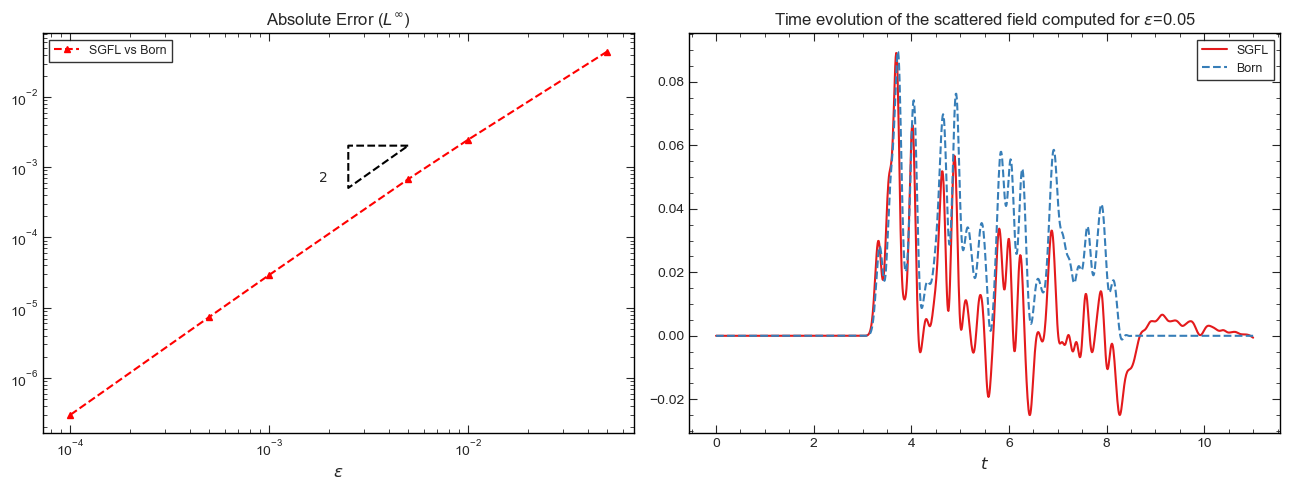

In [19]:
fig, (ax_curves, ax_fields) = plt.subplots(1,2, figsize=(13, 5))

# Visualisation of convergence curves
errors_sgfl_vs_born = []

epsilons = data['epsilon_list']

for eps in epsilons:
    eps = str(eps).replace('.', '_')

    u_sgfl = data[f'u_s_{eps}']
    u_born = data[f'u_B_{eps}']

    err_sgfl_vs_born = np.linalg.norm(u_sgfl-u_born, ord=np.inf)
    errors_sgfl_vs_born.append(err_sgfl_vs_born)

error_curves = {
    'SGFL vs Born': errors_sgfl_vs_born 
}


plot_convergence_curves(ax_curves, epsilons, **error_curves)

add_convergence_triangle(ax_curves, epsilons[2], errors_sgfl_vs_born[2], 2, size_x=0.5, text_offset=0.2, shift_y=3)


# Visualisation of scattered fields 
eps = 0.05
eps_str = str(eps).replace('.', '_')
N = int(data['T']/data['dt'])
t = np.linspace(0, data['T'], N+1)

u_sgfl = data[f'u_s_{eps_str}']
u_born = data[f'u_B_{eps_str}']

scattered_fields = {
    'SGFL': u_sgfl,
    'Born': u_born
}

plot_scattered_fields(ax_fields, t, eps, **scattered_fields)